Các biến (keys) được lưu trong file:
['R_pred', 'segment_ids', 'matrix_index', 'split', 'horizon', 'pred_idx', 'source_sample_id', 'timestamp_local', 'matrix_contract']
--- Key: 'R_pred' ---
Kích thước (Shape): (3696, 3696)
Kiểu dữ liệu (Dtype): float16
Dữ liệu mẫu (5 phần tử đầu): [ 1.       0.01542 -0.03555 -0.0356  -0.02817]
------------------------------


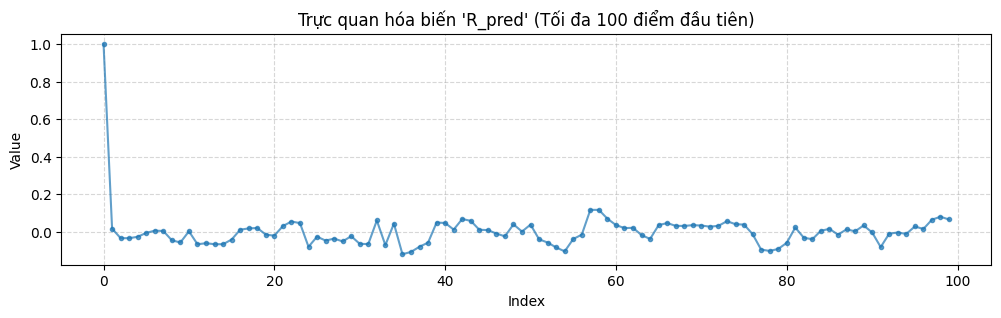

--- Key: 'segment_ids' ---
Kích thước (Shape): (3696,)
Kiểu dữ liệu (Dtype): int64
Dữ liệu mẫu (5 phần tử đầu): [0 1 2 3 4]
------------------------------


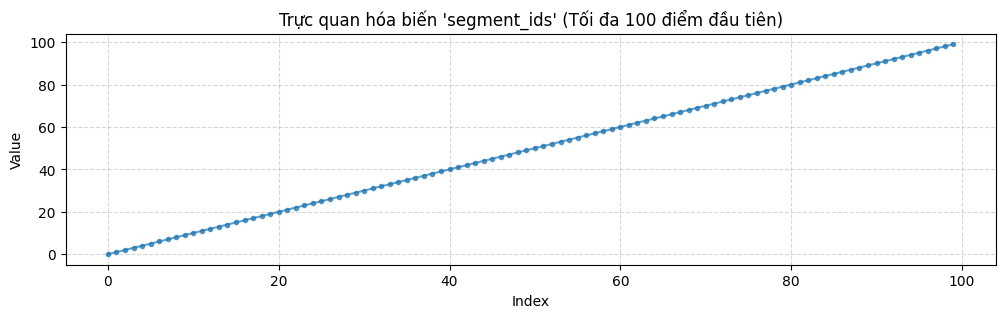

--- Key: 'matrix_index' ---
Kích thước (Shape): (3696,)
Kiểu dữ liệu (Dtype): int64
Dữ liệu mẫu (5 phần tử đầu): [0 1 2 3 4]
------------------------------


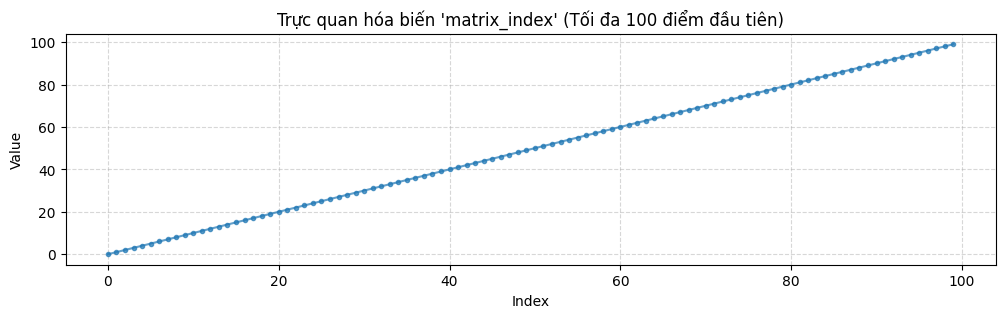

--- Key: 'split' ---
Kích thước (Shape): ()
Kiểu dữ liệu (Dtype): <U4
Dữ liệu mẫu (5 phần tử đầu): ['test']
------------------------------
--- Key: 'horizon' ---
Kích thước (Shape): (1,)
Kiểu dữ liệu (Dtype): int64
Dữ liệu mẫu (5 phần tử đầu): [1]
------------------------------


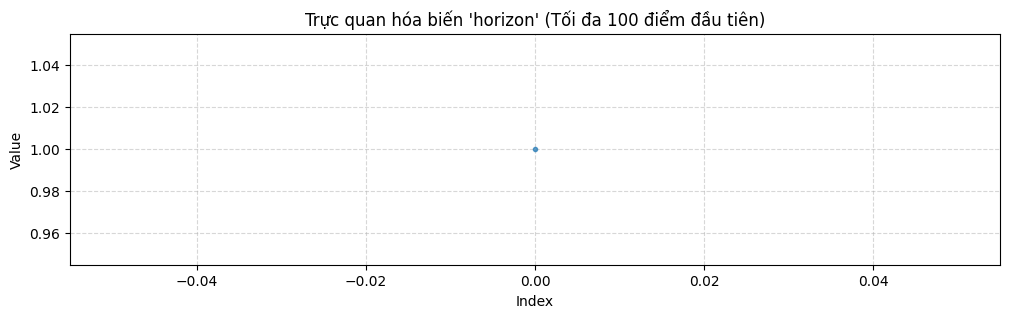

--- Key: 'pred_idx' ---
Kích thước (Shape): (1,)
Kiểu dữ liệu (Dtype): int64
Dữ liệu mẫu (5 phần tử đầu): [0]
------------------------------


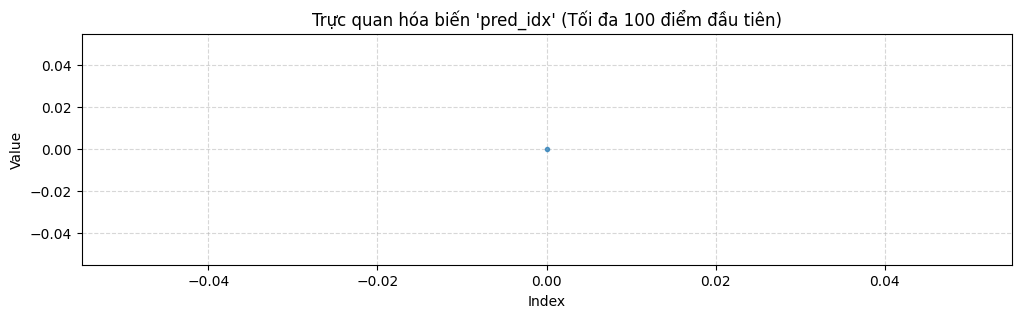

--- Key: 'source_sample_id' ---
Kích thước (Shape): (1,)
Kiểu dữ liệu (Dtype): int64
Dữ liệu mẫu (5 phần tử đầu): [0]
------------------------------


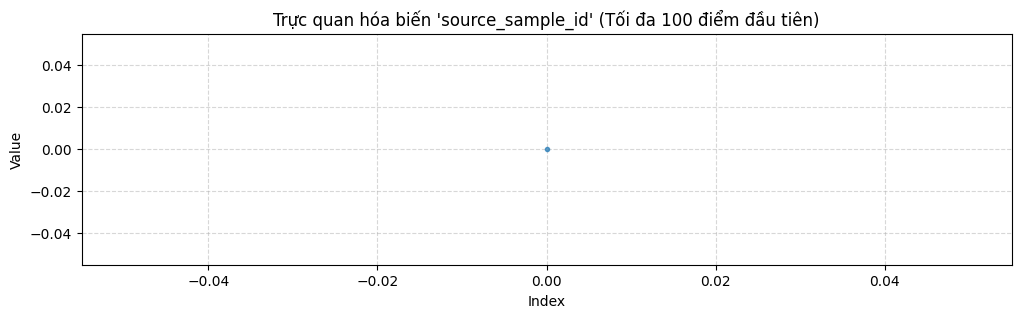

--- Key: 'timestamp_local' ---
Kích thước (Shape): ()
Kiểu dữ liệu (Dtype): <U19
Dữ liệu mẫu (5 phần tử đầu): ['1970-01-01 00:00:00']
------------------------------
--- Key: 'matrix_contract' ---
Kích thước (Shape): ()
Kiểu dữ liệu (Dtype): <U79
Dữ liệu mẫu (5 phần tử đầu): ['R_pred[i,j] is predicted correlation between segment_ids[i] and segment_ids[j].']
------------------------------


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sử dụng r"" (raw string) để Python không bị lỗi với các dấu gạch chéo ngược (\) trên Windows
file_path = r"C:\1_Workspace\4_Nam_4\2_HocKy_252\1_Do_An_Chuyen_Nganh\Urban-Traffic-Links\BE\ml_workspace\data\dmfm_predictions\test\h1\bundles\dmfm_pred_test_h1_idx000000.npz"

try:
    # Load data từ file .npz
    # allow_pickle=True đôi khi cần thiết nếu file chứa object Python, nhưng thường traffic data là số thực (float)
    data = np.load(file_path, allow_pickle=True)
    
    print(f"Các biến (keys) được lưu trong file:")
    print(data.files)
    print("=" * 50)
    
    # Lặp qua từng biến để xem thông tin chi tiết
    for key in data.files:
        arr = data[key]
        print(f"--- Key: '{key}' ---")
        print(f"Kích thước (Shape): {arr.shape}")
        print(f"Kiểu dữ liệu (Dtype): {arr.dtype}")
        
        # In ra 5 giá trị đầu tiên (làm phẳng mảng để dễ in)
        print(f"Dữ liệu mẫu (5 phần tử đầu): {arr.flatten()[:5]}")
        print("-" * 30)
        
        # --- TUỲ CHỌN: Vẽ đồ thị trực quan ---
        # Nếu mảng là 1D hoặc 2D, vẽ thử 100 điểm đầu tiên để xem xu hướng dự đoán
        if arr.size > 0 and (arr.ndim == 1 or arr.ndim == 2):
            plt.figure(figsize=(12, 3))
            # Flatten để vẽ dễ dàng hơn nếu là mảng 2D (ví dụ: [nodes, time_steps])
            plt.plot(arr.flatten()[:100], marker='.', linestyle='-', alpha=0.7)
            plt.title(f"Trực quan hóa biến '{key}' (Tối đa 100 điểm đầu tiên)")
            plt.xlabel("Index")
            plt.ylabel("Value")
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.show()

except FileNotFoundError:
    print("❌ Không tìm thấy file! Bạn hãy kiểm tra lại xem đường dẫn đã chính xác chưa nhé.")
except Exception as e:
    print(f"❌ Có lỗi xảy ra trong quá trình đọc file: {e}")